In [1]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import scipy.ndimage
import scipy.optimize

In [2]:
begin = (185, 780)
end = (513, 270)

In [3]:
with rasterio.open("../Dutch Bill Creek-pass2.tif") as file:
    gully = file.read(1)[7800:8750, 7750:8500]

In [4]:
with rasterio.open("../Dutch Bill Creek-pass3-8.tif") as file:
    connected = file.read(1)[7800:8750, 7750:8500]

mapping, connected = np.unique_inverse(connected)
num_connected = len(mapping)

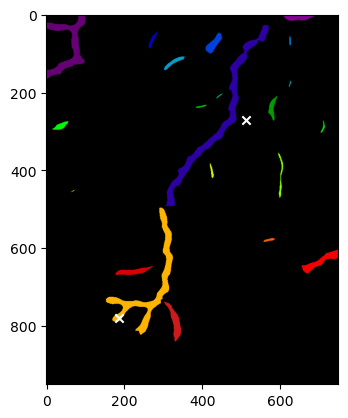

In [5]:
fig, ax = plt.subplots()

ax.imshow(connected, vmin=0, vmax=num_connected, cmap="nipy_spectral")

ax.scatter([begin[0], end[0]], [begin[1], end[1]], marker="x", color="white")

None

In [6]:
outside = connected == 0
indices = scipy.ndimage.distance_transform_edt(
    outside, return_distances=False, return_indices=True
)
connected_nearest = connected[tuple(indices)]

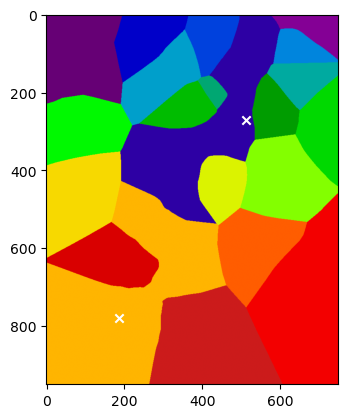

In [7]:
fig, ax = plt.subplots()

ax.imshow(connected_nearest, vmin=0, vmax=num_connected, cmap="nipy_spectral")

ax.scatter([begin[0], end[0]], [begin[1], end[1]], marker="x", color="white")

None

In [9]:
begin_color = connected_nearest[begin[1], begin[0]]
end_color = connected_nearest[end[1], end[0]]

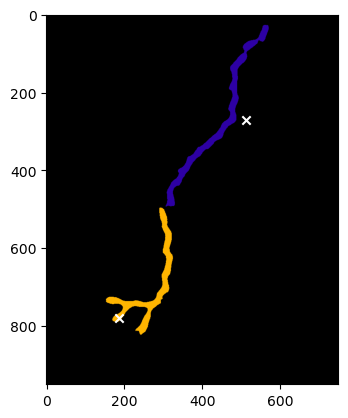

In [10]:
fig, ax = plt.subplots()

ax.imshow(connected * ((connected == begin_color) | (connected == end_color)), vmin=0, vmax=num_connected, cmap="nipy_spectral")

ax.scatter([begin[0], end[0]], [begin[1], end[1]], marker="x", color="white")

None